In [ ]:
!pip install tsfresh prophet scikit-learn pandas numpy matplotlib seaborn

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.1 MB 6.7 MB/s eta 0:00:02
   ------- -------------------------------- 2.4/12.1 MB 6.1 MB/s eta 0:00:02
   ------------ --------------------------- 3.7/12.1 MB 5.8 MB/s eta 0:00:02
   ---------------- ----------------------- 5.0/12.1 MB 5.8 MB/s eta 0:00:02
   ------------------- -------------------- 5.8/12.1 MB 5.5 MB/s eta 0:00:02
   ----------------------- ---------------- 7.1/12.1 MB 5.5 MB/s eta 0:00:01
   --------------------------- ------------ 8.4/12.1 MB 5.7 MB/s eta 0:00:01
   -------------------------------- ------- 9.7/12.1 MB 5.6 MB/s eta 0:00:01
   ----------------------------------- ---- 10.7/12.1 MB 5.5 MB/s eta 0:00:01
   -------------------------------------- - 11.8/12.1 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 5.4 MB/s  0:00:02
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   -----------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from tsfresh import extract_features
from tsfresh.feature_extraction import MinimalFCParameters

from prophet import Prophet

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [3]:
df = pd.read_csv("Fitness_Health_Tracking_Dataset.csv")

# Parse date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=True)

# Quick preprocessing (same as your app)
numeric_candidates = [
    "Hours_Slept", "Water_Intake (Liters)",
    "Active_Minutes", "Heart_Rate (bpm)",
    "Steps_Taken", "Calories_Burned",
    "Stress_Level (1-10)"
]
numeric_cols = [c for c in numeric_candidates if c in df.columns]

df[numeric_cols] = df.groupby("User_ID")[numeric_cols].transform(
    lambda x: x.interpolate(method="linear")
)
df[numeric_cols] = df.groupby("User_ID")[numeric_cols].transform(
    lambda x: x.ffill().bfill()
)

if "Workout_Type" in df.columns:
    df["Workout_Type"] = df["Workout_Type"].fillna("No Workout")

print("✅ Data loaded and cleaned")
print("Shape:", df.shape)
df.head()

✅ Data loaded and cleaned
Shape: (36500, 16)


,User_ID,Full Name,Date,Age,Gender,Height (cm),Weight (kg),Steps_Taken,Calories_Burned,Hours_Slept,Water_Intake (Liters),Active_Minutes,Heart_Rate (bpm),Workout_Type,Stress_Level (1-10),Mood
0,1,Sara Martinez,2023-01-01,19,Female,191,80,11405,1862,7.021201,3.440508,80.0,84.0,Yoga,2,Happy
1,1,Sara Martinez,2023-01-02,19,Female,191,80,7010,1806,7.594509,3.103590,47.0,72.0,Cardio,9,Neutral
2,1,Sara Martinez,2023-01-03,19,Female,191,80,18942,2274,8.167817,3.814843,46.0,85.0,Yoga,6,Sad
3,1,Sara Martinez,2023-01-04,19,Female,191,80,13778,2656,7.453552,3.508636,105.0,77.0,Yoga,2,Sad
4,1,Sara Martinez,2023-01-05,19,Female,191,80,10247,3571,5.132654,2.576740,53.0,61.0,Yoga,8,Sad


In [4]:
# TSFresh needs: id column, time column, value column
# We will extract features for Heart Rate per user

ts_df = df[["User_ID", "Date", "Heart_Rate (bpm)"]].copy()
ts_df = ts_df.dropna()
ts_df = ts_df.sort_values(["User_ID", "Date"])
ts_df = ts_df.rename(columns={
    "User_ID": "id",
    "Date": "time",
    "Heart_Rate (bpm)": "value"
})

print("TSFresh input shape:", ts_df.shape)
print("\nFormat check:")
ts_df.head(10)

TSFresh input shape: (36500, 3)

Format check:


,id,time,value
0,1,2023-01-01,84.0
1,1,2023-01-02,72.0
2,1,2023-01-03,85.0
3,1,2023-01-04,77.0
4,1,2023-01-05,61.0
5,1,2023-01-06,80.0
6,1,2023-01-07,70.0
7,1,2023-01-08,88.0
8,1,2023-01-09,74.0
9,1,2023-01-10,80.0


In [5]:
# Using MinimalFCParameters to keep it fast
# Full extraction has 700+ features and takes very long

print("⏳ Extracting TSFresh features... (may take 1-2 minutes)")

features = extract_features(
    ts_df,
    column_id="id",
    column_sort="time",
    column_value="value",
    default_fc_parameters=MinimalFCParameters(),
    disable_progressbar=False
)

# Drop columns with all NaN
features = features.dropna(axis=1, how="all")

print(f"\n✅ TSFresh extraction complete!")
print(f"Feature matrix shape: {features.shape}")
print(f"Users (rows): {features.shape[0]}")
print(f"Features (columns): {features.shape[1]}")
features.head()

⏳ Extracting TSFresh features... (may take 1-2 minutes)


Feature Extraction: 100%|██████████| 20/20 [00:07<00:00,  2.73it/s]


✅ TSFresh extraction complete!
Feature matrix shape: (100, 10)
Users (rows): 100
Features (columns): 10


,value__sum_values,value__median,value__mean,value__length,value__standard_deviation,value__variance,value__root_mean_square,value__maximum,value__absolute_maximum,value__minimum
1,28973.5,80.0,79.379452,365.0,11.898534,141.575118,80.266260,99.0,99.0,60.0
2,29394.0,81.0,80.531507,365.0,11.394410,129.832569,81.333610,99.0,99.0,60.0
3,29045.5,79.0,79.576712,365.0,11.824557,139.820143,80.450440,99.0,99.0,60.0
4,29540.0,81.0,80.931507,365.0,11.526894,132.869281,81.748260,99.0,99.0,60.0
5,28900.0,79.0,79.178082,365.0,11.632079,135.305273,80.027957,99.0,99.0,60.0


In [6]:
print("📊 TSFresh Feature Matrix — First 5 Users\n")
print(f"Total statistical features extracted: {features.shape[1]}")
print("\nFeature names:")
for i, col in enumerate(features.columns):
    print(f"  {i+1}. {col}")

📊 TSFresh Feature Matrix — First 5 Users

Total statistical features extracted: 10

Feature names:
  1. value__sum_values
  2. value__median
  3. value__mean
  4. value__length
  5. value__standard_deviation
  6. value__variance
  7. value__root_mean_square
  8. value__maximum
  9. value__absolute_maximum
  10. value__minimum


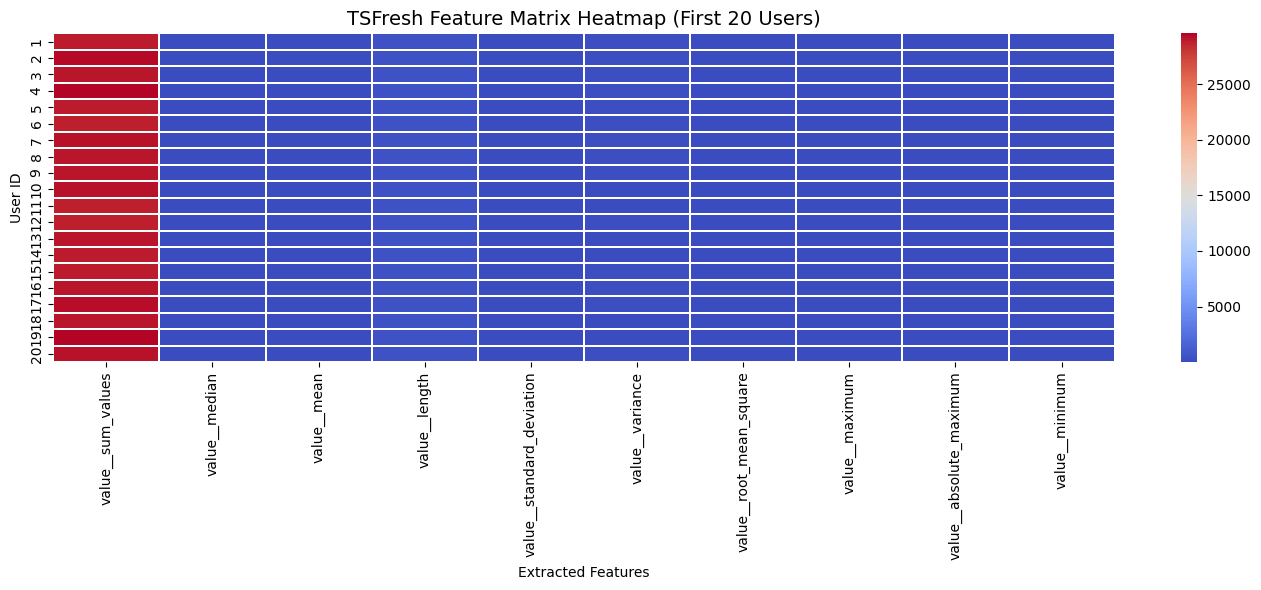

✅ TSFresh feature matrix screenshot ready


In [7]:
plt.figure(figsize=(14, 6))
sns.heatmap(
    features.iloc[:20],   # first 20 users
    cmap="coolwarm",
    annot=False,
    linewidths=0.3
)
plt.title("TSFresh Feature Matrix Heatmap (First 20 Users)", fontsize=14)
plt.xlabel("Extracted Features")
plt.ylabel("User ID")
plt.tight_layout()
plt.show()

print("✅ TSFresh feature matrix screenshot ready")

In [8]:
features.to_csv("tsfresh_features.csv")
print("✅ TSFresh features saved to tsfresh_features.csv")

✅ TSFresh features saved to tsfresh_features.csv


In [9]:
# Aggregate daily mean across all users
prophet_hr = df.groupby("Date")["Heart_Rate (bpm)"].mean().reset_index()
prophet_hr.columns = ["ds", "y"]
prophet_hr = prophet_hr.dropna()
prophet_hr = prophet_hr.sort_values("ds")

print("Prophet input shape:", prophet_hr.shape)
print("\nSample:")
prophet_hr.head(10)

Prophet input shape: (365, 2)

Sample:


,ds,y
0,2023-01-01,78.550000
1,2023-01-02,81.245000
2,2023-01-03,80.765000
3,2023-01-04,80.263333
4,2023-01-05,78.741667
5,2023-01-06,78.305000
6,2023-01-07,78.570000
7,2023-01-08,79.510000
8,2023-01-09,79.895000
9,2023-01-10,79.695000


In [10]:
print("⏳ Fitting Prophet model on Heart Rate...")

model_hr = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    interval_width=0.80,          # 80% confidence interval
    changepoint_prior_scale=0.05  # controls trend flexibility
)

model_hr.fit(prophet_hr)

# Forecast 90 days into future
future_hr = model_hr.make_future_dataframe(periods=90)
forecast_hr = model_hr.predict(future_hr)

print("✅ Prophet model fitted successfully")
print("Forecast shape:", forecast_hr.shape)
forecast_hr[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10)

⏳ Fitting Prophet model on Heart Rate...


19:55:44 - cmdstanpy - INFO - Chain [1] start processing
19:55:45 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model fitted successfully
Forecast shape: (455, 19)


,ds,yhat,yhat_lower,yhat_upper
445,2024-03-21,79.016816,77.579327,80.393433
446,2024-03-22,78.973547,77.540607,80.478016
447,2024-03-23,78.581017,77.130603,79.924882
448,2024-03-24,78.625946,77.215705,80.043417
449,2024-03-25,78.777819,77.266917,80.191034
450,2024-03-26,78.776901,77.377954,80.175561
451,2024-03-27,78.874256,77.403589,80.248923
452,2024-03-28,78.880629,77.436651,80.316611
453,2024-03-29,78.853351,77.352410,80.321032
454,2024-03-30,78.478568,76.950909,80.073630


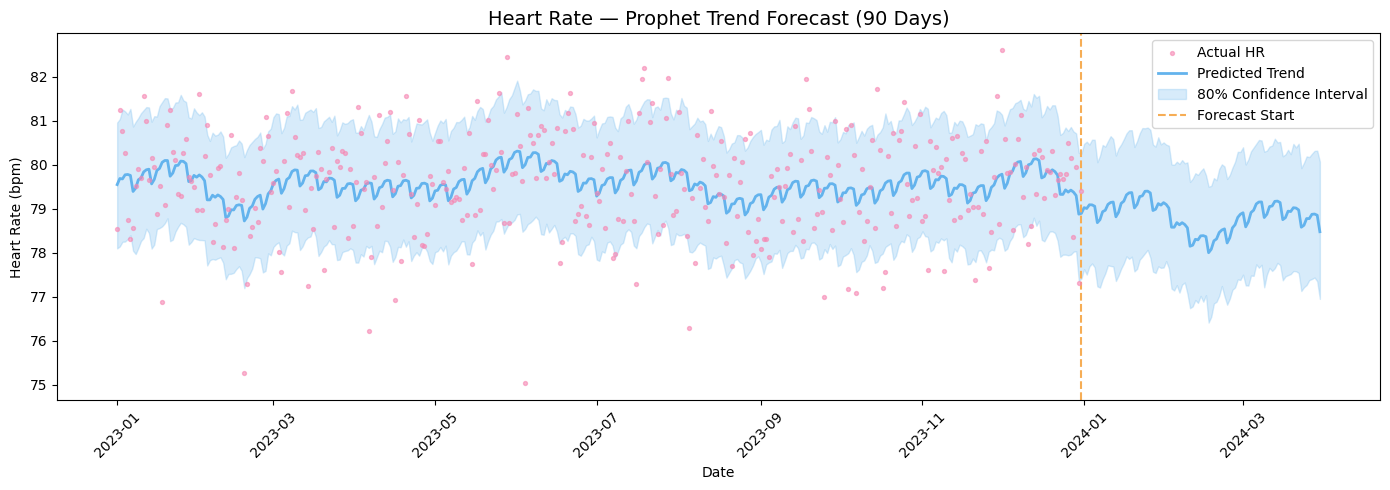

✅ Prophet trend graph screenshot ready


In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

# Actual data
ax.scatter(prophet_hr["ds"], prophet_hr["y"],
           color="#f687b3", s=8, alpha=0.6, label="Actual HR", zorder=3)

# Predicted trend line
ax.plot(forecast_hr["ds"], forecast_hr["yhat"],
        color="#63b3ed", linewidth=2, label="Predicted Trend")

# Confidence interval shading
ax.fill_between(
    forecast_hr["ds"],
    forecast_hr["yhat_lower"],
    forecast_hr["yhat_upper"],
    alpha=0.25, color="#63b3ed", label="80% Confidence Interval"
)

# Forecast region marker
forecast_start = prophet_hr["ds"].max()
ax.axvline(forecast_start, color="#f6ad55", linestyle="--",
           linewidth=1.5, label="Forecast Start")

ax.set_title("Heart Rate — Prophet Trend Forecast (90 Days)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Heart Rate (bpm)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✅ Prophet trend graph screenshot ready")

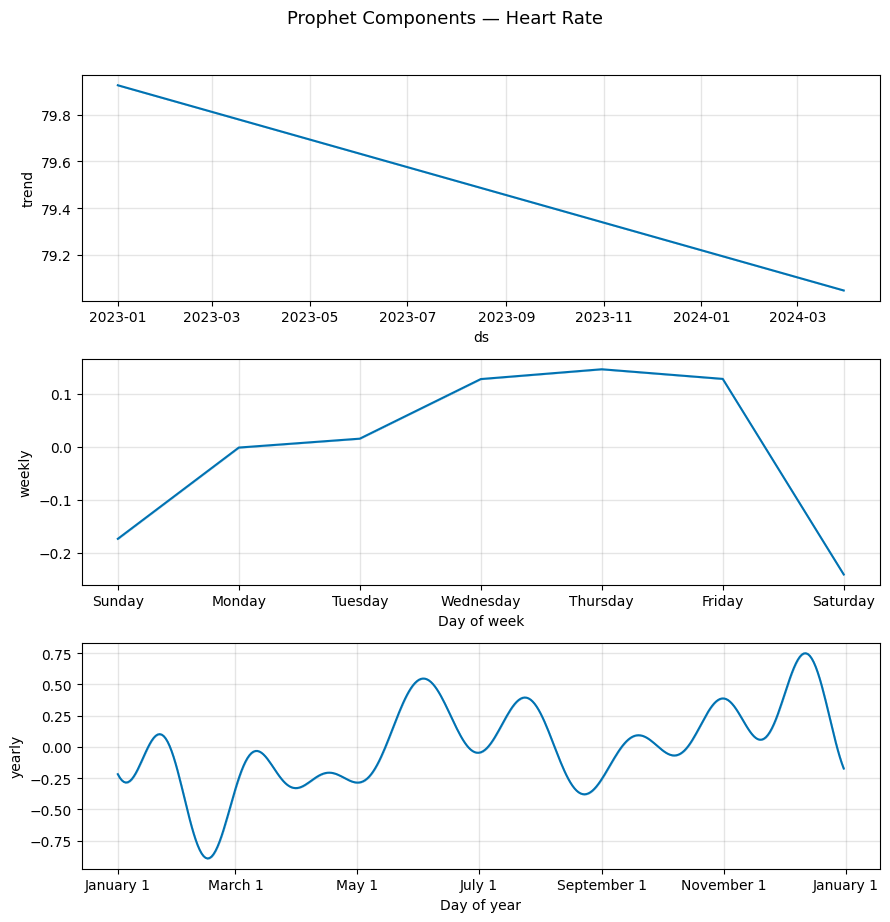

In [12]:
fig2 = model_hr.plot_components(forecast_hr)
plt.suptitle("Prophet Components — Heart Rate", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

19:58:41 - cmdstanpy - INFO - Chain [1] start processing
19:58:41 - cmdstanpy - INFO - Chain [1] done processing
19:58:41 - cmdstanpy - INFO - Chain [1] start processing
19:58:41 - cmdstanpy - INFO - Chain [1] done processing


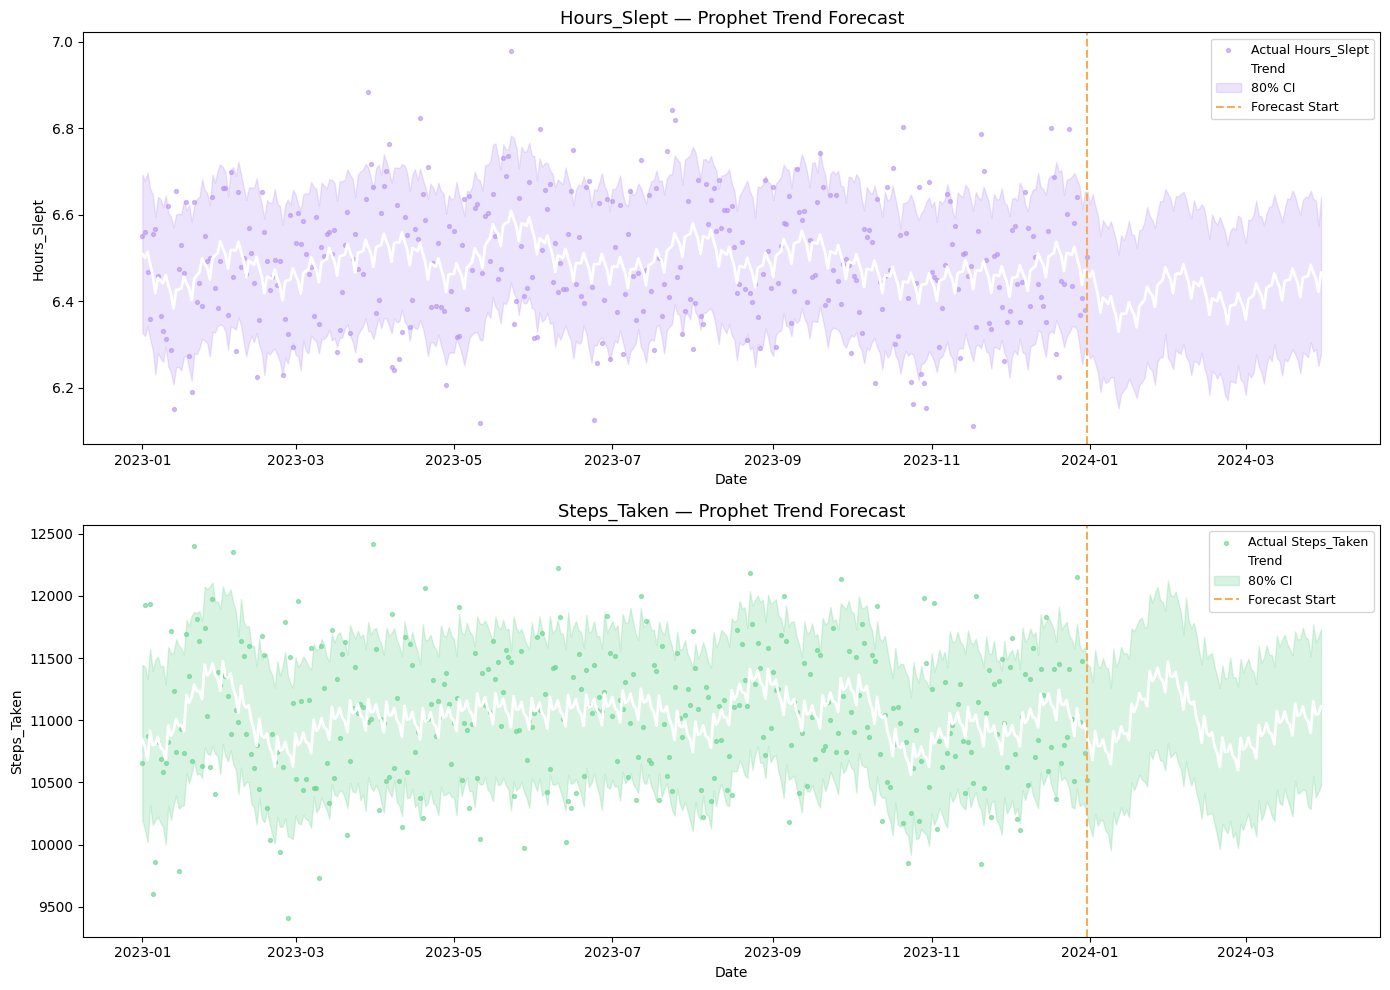

✅ Sleep and Steps Prophet graphs ready


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, metric, color in zip(
    axes,
    ["Hours_Slept", "Steps_Taken"],
    ["#b794f4", "#68d391"]
):
    daily = df.groupby("Date")[metric].mean().reset_index()
    daily.columns = ["ds", "y"]
    daily = daily.dropna().sort_values("ds")

    m = Prophet(
        weekly_seasonality=True,
        yearly_seasonality=True,
        interval_width=0.80,
        daily_seasonality=False
    )
    m.fit(daily)
    future = m.make_future_dataframe(periods=90)
    forecast = m.predict(future)

    ax.scatter(daily["ds"], daily["y"],
               color=color, s=8, alpha=0.6, label=f"Actual {metric}")
    ax.plot(forecast["ds"], forecast["yhat"],
            color="white", linewidth=2, label="Trend")
    ax.fill_between(forecast["ds"],
                    forecast["yhat_lower"], forecast["yhat_upper"],
                    alpha=0.25, color=color, label="80% CI")
    ax.axvline(daily["ds"].max(), color="#f6ad55",
               linestyle="--", linewidth=1.5, label="Forecast Start")
    ax.set_title(f"{metric} — Prophet Trend Forecast", fontsize=13)
    ax.set_xlabel("Date")
    ax.set_ylabel(metric)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("✅ Sleep and Steps Prophet graphs ready")

In [14]:
# Use user-level aggregated means as clustering features
cluster_features = df.groupby("User_ID")[numeric_cols].mean().round(3)
cluster_features = cluster_features.dropna()

print("Clustering feature matrix shape:", cluster_features.shape)
print("Users:", cluster_features.shape[0])
print("Features:", cluster_features.columns.tolist())
cluster_features.head()

Clustering feature matrix shape: (100, 7)
Users: 100
Features: ['Hours_Slept', 'Water_Intake (Liters)', 'Active_Minutes', 'Heart_Rate (bpm)', 'Steps_Taken', 'Calories_Burned', 'Stress_Level (1-10)']


,Hours_Slept,Water_Intake (Liters),Active_Minutes,Heart_Rate (bpm),Steps_Taken,Calories_Burned,Stress_Level (1-10)
User_ID,,,,,,,
1,6.471,2.778,74.652,79.379,11352.600,2723.737,5.589
2,6.461,2.746,73.966,80.532,10520.542,2812.512,5.471
3,6.435,2.746,73.418,79.577,11096.704,2751.742,5.384
4,6.486,2.693,76.275,80.932,11492.359,2774.929,5.340
5,6.410,2.797,76.279,79.178,10973.901,2688.419,5.438


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

print("✅ Features scaled with StandardScaler")
print("Scaled shape:", X_scaled.shape)
print("Mean after scaling (should be ~0):", X_scaled.mean().round(4))
print("Std after scaling (should be ~1):", X_scaled.std().round(4))

✅ Features scaled with StandardScaler
Scaled shape: (100, 7)
Mean after scaling (should be ~0): -0.0
Std after scaling (should be ~1): 1.0


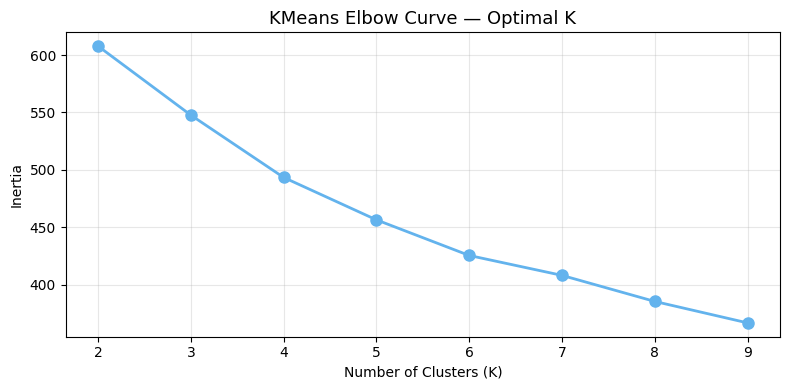

✅ Choose K at the elbow point above


In [16]:
inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, "o-", color="#63b3ed", linewidth=2, markersize=8)
plt.title("KMeans Elbow Curve — Optimal K", fontsize=13)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Choose K at the elbow point above")

In [17]:
OPTIMAL_K = 3   # change based on elbow curve above

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

cluster_features["KMeans_Cluster"] = kmeans_labels

print(f"✅ KMeans fitted with K={OPTIMAL_K}")
print("\nCluster distribution:")
print(cluster_features["KMeans_Cluster"].value_counts().sort_index())

✅ KMeans fitted with K=3

Cluster distribution:
KMeans_Cluster
0    27
1    29
2    44
Name: count, dtype: int64


In [18]:
EPS = 1.5
MIN_SAMPLES = 3

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(X_scaled)

cluster_features["DBSCAN_Cluster"] = dbscan_labels

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"✅ DBSCAN fitted — eps={EPS}, min_samples={MIN_SAMPLES}")
print(f"Clusters found: {n_clusters}")
print(f"Noise points (outliers): {n_noise}")
print("\nCluster distribution:")
print(cluster_features["DBSCAN_Cluster"].value_counts().sort_index())

✅ DBSCAN fitted — eps=1.5, min_samples=3
Clusters found: 3
Noise points (outliers): 66

Cluster distribution:
DBSCAN_Cluster
-1    66
 0    28
 1     3
 2     3
Name: count, dtype: int64


In [19]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_ * 100
print(f"✅ PCA complete")
print(f"PC1 explains: {var_explained[0]:.1f}% variance")
print(f"PC2 explains: {var_explained[1]:.1f}% variance")
print(f"Total explained: {sum(var_explained):.1f}%")

✅ PCA complete
PC1 explains: 19.1% variance
PC2 explains: 17.9% variance
Total explained: 37.1%


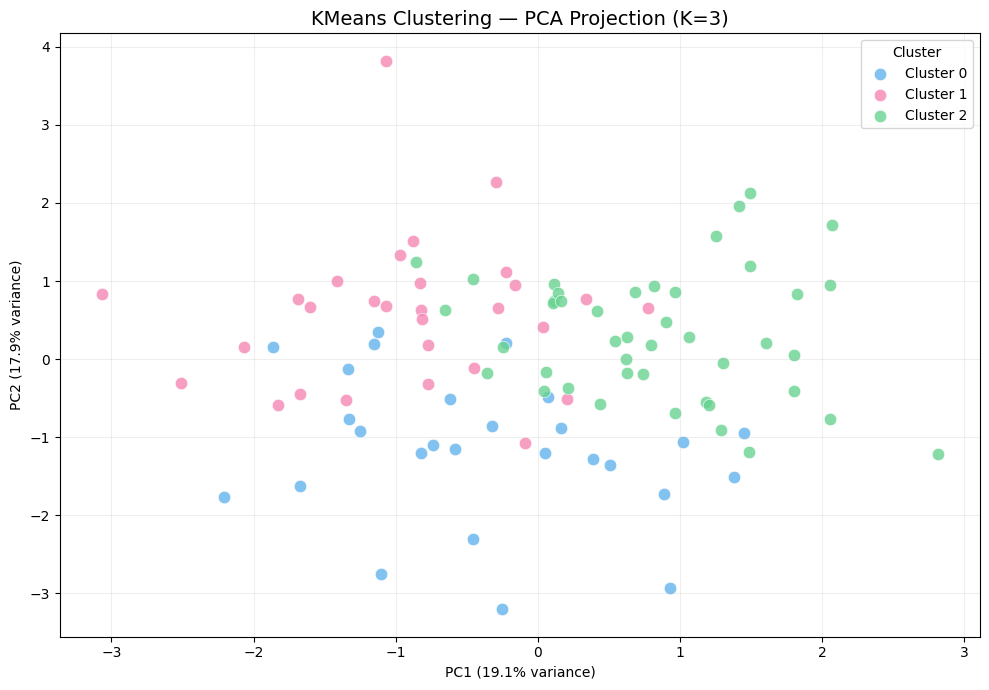

✅ KMeans PCA clustering plot ready — screenshot this


In [20]:
palette = ["#63b3ed", "#f687b3", "#68d391", "#f6ad55", "#b794f4", "#fc8181"]

plt.figure(figsize=(10, 7))

for cluster_id in sorted(set(kmeans_labels)):
    mask = kmeans_labels == cluster_id
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=palette[cluster_id % len(palette)],
        label=f"Cluster {cluster_id}",
        s=80, alpha=0.8, edgecolors="white", linewidths=0.5
    )

plt.title(f"KMeans Clustering — PCA Projection (K={OPTIMAL_K})", fontsize=14)
plt.xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
plt.legend(title="Cluster")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("✅ KMeans PCA clustering plot ready — screenshot this")

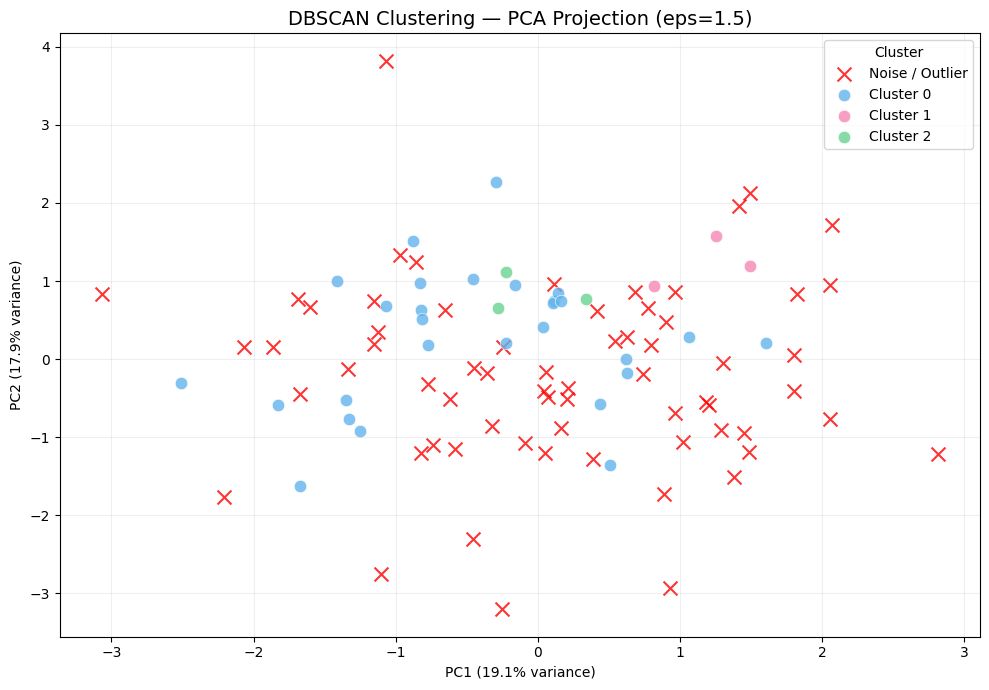

✅ DBSCAN PCA clustering plot ready — screenshot this


In [21]:
plt.figure(figsize=(10, 7))

unique_labels = sorted(set(dbscan_labels))
for label in unique_labels:
    mask = dbscan_labels == label
    if label == -1:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c="red", marker="x", s=100,
                    label="Noise / Outlier", alpha=0.8, linewidths=1.5)
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=palette[label % len(palette)],
                    label=f"Cluster {label}",
                    s=80, alpha=0.8, edgecolors="white", linewidths=0.5)

plt.title(f"DBSCAN Clustering — PCA Projection (eps={EPS})", fontsize=14)
plt.xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
plt.legend(title="Cluster")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("✅ DBSCAN PCA clustering plot ready — screenshot this")

⏳ Running t-SNE... (takes ~30 seconds)


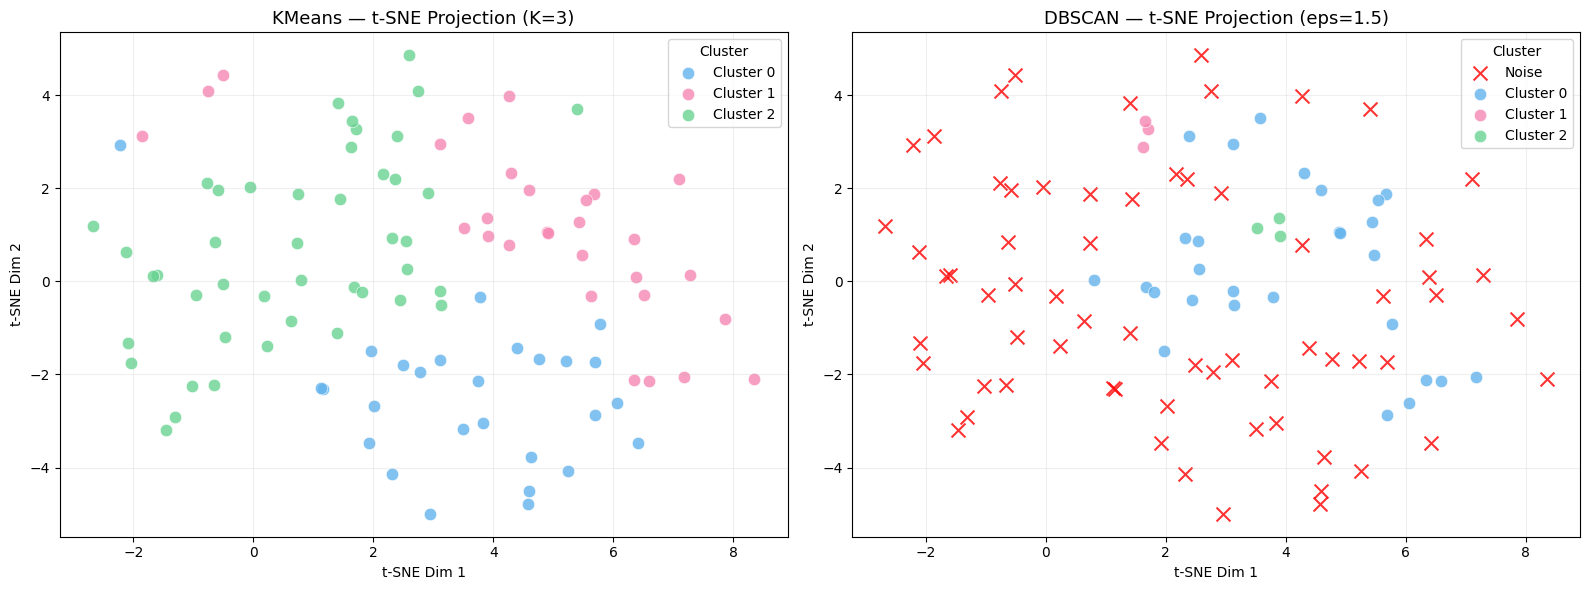

✅ t-SNE clustering plot ready — screenshot this


In [22]:
print("⏳ Running t-SNE... (takes ~30 seconds)")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KMeans t-SNE
for cluster_id in sorted(set(kmeans_labels)):
    mask = kmeans_labels == cluster_id
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=palette[cluster_id % len(palette)],
                    label=f"Cluster {cluster_id}",
                    s=80, alpha=0.8, edgecolors="white", linewidths=0.5)
axes[0].set_title(f"KMeans — t-SNE Projection (K={OPTIMAL_K})", fontsize=13)
axes[0].set_xlabel("t-SNE Dim 1")
axes[0].set_ylabel("t-SNE Dim 2")
axes[0].legend(title="Cluster")
axes[0].grid(alpha=0.2)

# DBSCAN t-SNE
for label in sorted(set(dbscan_labels)):
    mask = dbscan_labels == label
    if label == -1:
        axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                        c="red", marker="x", s=100,
                        label="Noise", alpha=0.8, linewidths=1.5)
    else:
        axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                        c=palette[label % len(palette)],
                        label=f"Cluster {label}",
                        s=80, alpha=0.8, edgecolors="white", linewidths=0.5)
axes[1].set_title(f"DBSCAN — t-SNE Projection (eps={EPS})", fontsize=13)
axes[1].set_xlabel("t-SNE Dim 1")
axes[1].set_ylabel("t-SNE Dim 2")
axes[1].legend(title="Cluster")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("✅ t-SNE clustering plot ready — screenshot this")

📊 KMeans Cluster Profiles — Average values per cluster:

                Hours_Slept  Water_Intake (Liters)  Active_Minutes  Heart_Rate (bpm)  Steps_Taken  Calories_Burned  Stress_Level (1-10)
KMeans_Cluster                                                                                                                         
0                      6.43                   2.72           74.74             79.13     10882.86          2743.51                 5.47
1                      6.54                   2.76           75.16             79.47     11134.97          2711.21                 5.49
2                      6.50                   2.74           73.66             79.91     11062.73          2774.41                 5.52


<Figure size 1200x500 with 0 Axes>

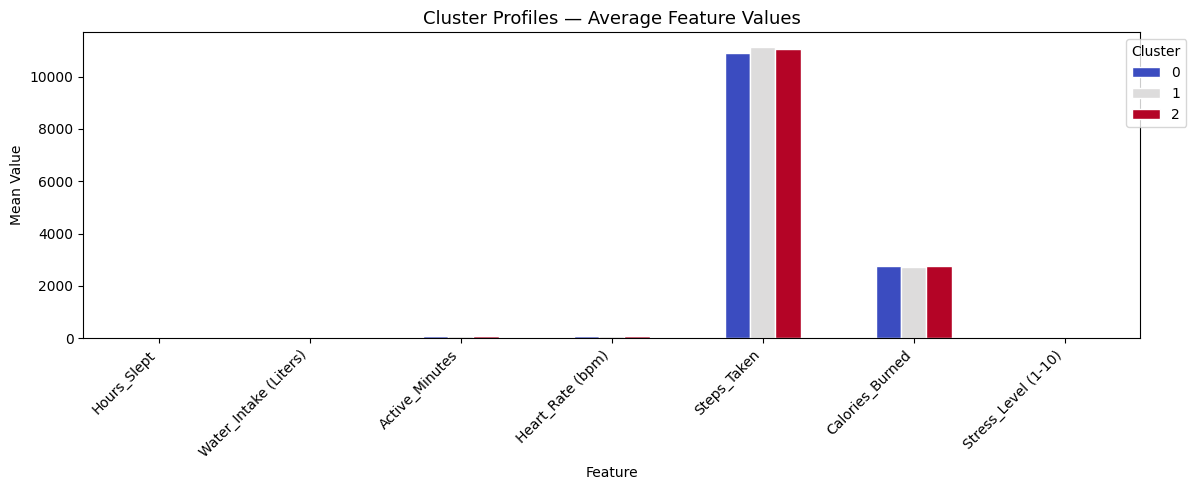

In [23]:
profile = cluster_features.groupby("KMeans_Cluster")[numeric_cols].mean().round(2)

print("📊 KMeans Cluster Profiles — Average values per cluster:\n")
print(profile.to_string())

plt.figure(figsize=(12, 5))
profile.T.plot(kind="bar", figsize=(12, 5), colormap="coolwarm", edgecolor="white")
plt.title("Cluster Profiles — Average Feature Values", fontsize=13)
plt.xlabel("Feature")
plt.ylabel("Mean Value")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [24]:
print("=" * 55)
print("   MILESTONE 2 SUMMARY")
print("=" * 55)
print(f"✅ TSFresh features extracted: {features.shape[1]} features")
print(f"   across {features.shape[0]} users")
print()
print(f"✅ Prophet models fitted: Heart Rate, Sleep, Steps")
print(f"   Forecast horizon: 90 days")
print(f"   Confidence interval: 80%")
print()
print(f"✅ KMeans: {OPTIMAL_K} clusters identified")
print(f"✅ DBSCAN: {n_clusters} clusters, {n_noise} noise/outlier users")
print()
print("📸 Screenshots needed:")
print("   1. Cell 8  — TSFresh feature matrix heatmap")
print("   2. Cell 12 — Prophet HR trend with confidence band")
print("   3. Cell 21 — KMeans PCA scatter plot")
print("   4. Cell 22 — DBSCAN PCA scatter plot")
print("   5. Cell 23 — t-SNE projection (both models)")
print("=" * 55)

   MILESTONE 2 SUMMARY
✅ TSFresh features extracted: 10 features
   across 100 users

✅ Prophet models fitted: Heart Rate, Sleep, Steps
   Forecast horizon: 90 days
   Confidence interval: 80%

✅ KMeans: 3 clusters identified
✅ DBSCAN: 3 clusters, 66 noise/outlier users

📸 Screenshots needed:
   1. Cell 8  — TSFresh feature matrix heatmap
   2. Cell 12 — Prophet HR trend with confidence band
   3. Cell 21 — KMeans PCA scatter plot
   4. Cell 22 — DBSCAN PCA scatter plot
   5. Cell 23 — t-SNE projection (both models)
